In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
USAGE_CSV = "gen8ou_usage.csv"
ITEMS_CSV = "gen8ou_items.csv"
TEAM_CSV = "gen8ou_teams.csv"
TEAMMATES_CSV = "gen8ou_teammates.csv"

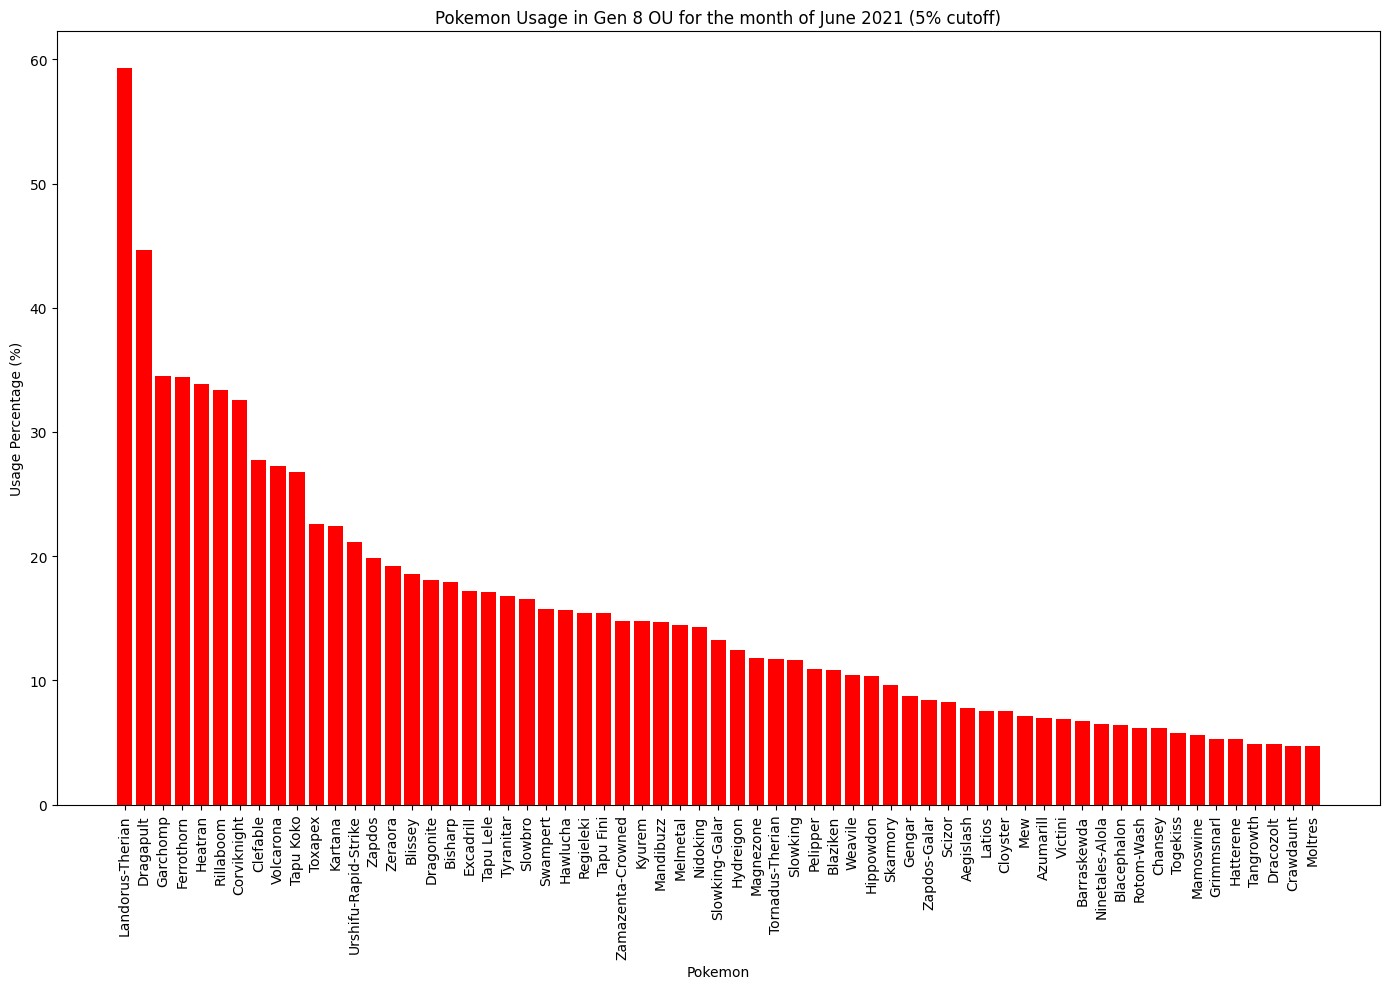

Number of Pokémon with over 10% usage: 40


In [18]:
usage_df = pd.read_csv(USAGE_CSV)

total_battles = usage_df["total_battles"].iloc[0]
usage_df["raw_percent"] = (usage_df["raw_usage"] / total_battles) * 100
filtered = usage_df[usage_df["raw_percent"] >= 4.52]
filtered = filtered.sort_values("raw_percent", ascending=False)

plt.figure(figsize=(14,10))
plt.bar(filtered["pokemon"], filtered["raw_percent"], color = "red")
plt.xticks(rotation=90)
plt.ylabel("Usage Percentage (%)")
plt.xlabel("Pokemon")
plt.title("Pokemon Usage in Gen 8 OU for the month of June 2021 (5% cutoff)")
plt.tight_layout()
plt.show()
over_10_count = (usage_df["raw_percent"] > 10.0).sum()
print("Number of Pokémon with over 10% usage:", over_10_count)

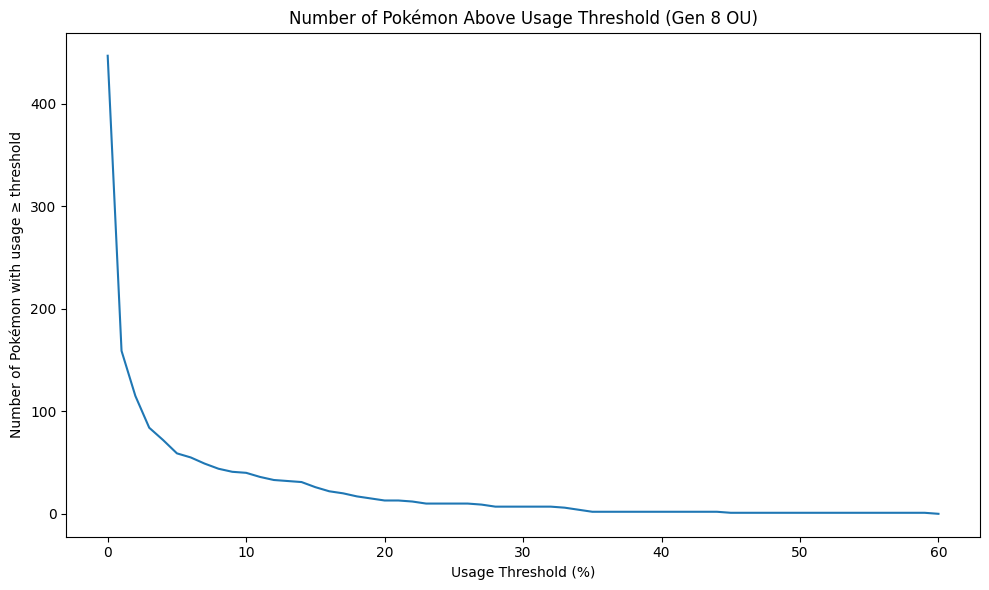

In [5]:
max_usage = usage_df["raw_percent"].max()
thresholds = np.arange(0, max_usage + 1, 1)
counts = [(usage_df["raw_percent"] >= t).sum() for t in thresholds]

plt.figure(figsize=(10,6))
plt.plot(thresholds, counts)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Gen 8 OU)")
plt.tight_layout()
plt.show()

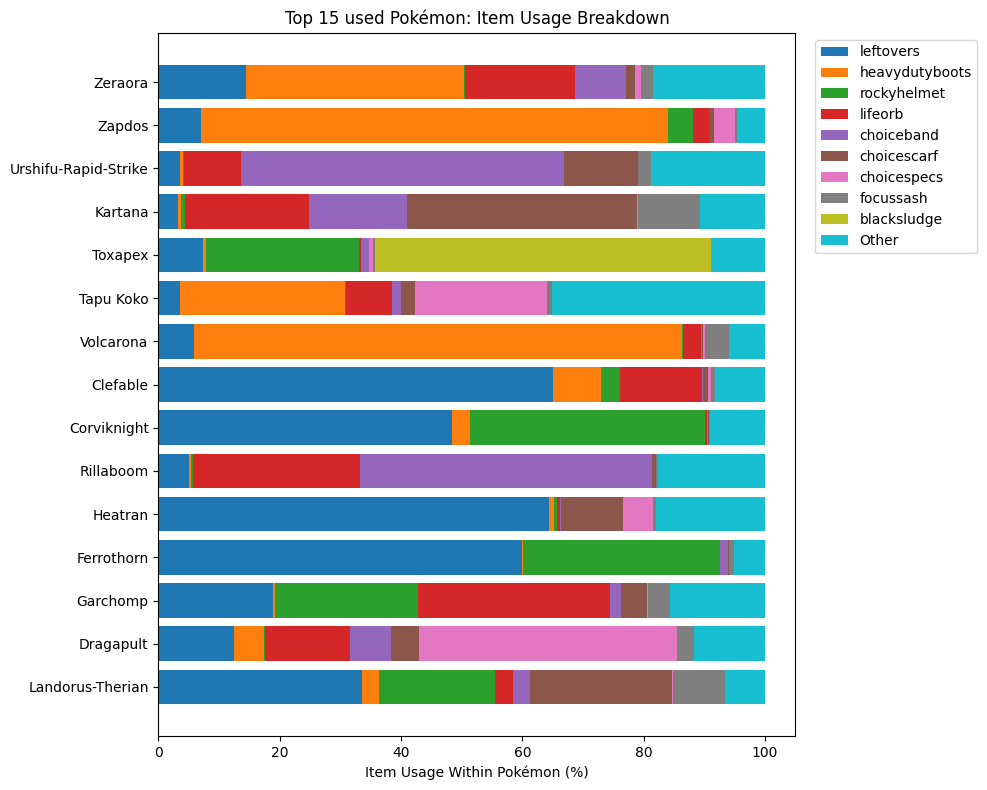

In [22]:

TOP_N_POKEMON = 15
TOP_N_ITEMS = 9
items_df = pd.read_csv(ITEMS_CSV)

top_mons = (
    usage_df.sort_values("raw_percent", ascending=False)
    .head(TOP_N_POKEMON)["pokemon"]
    .tolist()
)

items_sub = items_df[items_df["pokemon"].isin(top_mons)].copy()
items_sub = items_sub.set_index("pokemon")
items_sub = items_sub.apply(pd.to_numeric, errors="coerce").fillna(0)
items_sub = items_sub.reindex(top_mons)

top_items = items_sub.sum(axis=0).sort_values(ascending=False).head(TOP_N_ITEMS).index.tolist()

row_totals = items_sub.sum(axis=1).replace(0, 1)
pct = (items_sub.div(row_totals, axis=0) * 100)

pct_top = pct[top_items].copy()
pct_top["Other"] = 100 - pct_top.sum(axis=1)

plt.figure(figsize=(10, 8))
left = [0] * len(pct_top.index)

for col in pct_top.columns:
    plt.barh(pct_top.index, pct_top[col].values, left=left, label=col)
    left = [l + v for l, v in zip(left, pct_top[col].values)]

plt.xlabel("Item Usage Within Pokémon (%)")
plt.title(f"Top {TOP_N_POKEMON} used Pokémon: Item Usage Breakdown")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
